# QAOA Model Evaluation
Compares ADAPT baseline against multiple GPT/LLaMA-based QAOA circuit generators.

In [43]:
# ------------------------
# IMPORTS
# ------------------------

import re
import random
import numpy as np
import torch
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from src.adapt_utils import get_combined_res_df
from src.model_interface import QAOA_GPT

pd.set_option("display.max_columns", None)

In [44]:
# ------------------------
# CONFIG
# ------------------------

SEED = 1337
data_input_path = "./ADAPT.jl_results/test/10_nodes"

# Model configs — each entry is a dict with required keys: ckpt, data_dir.
# Optional key: name (auto-extracted from ckpt filename if omitted).
# Auto-extraction: splits filename by "_", takes element[0] as arch and element[3] as method.
# Example: "llama_ckpt_5500_gnn_ar_0_924__er_0_006.pt" → "LLaMA-GNN"
# If name is provided explicitly, it overrides auto-extraction.
MODEL_CONFIGS = [
    dict(
        ckpt="nanoGPT/out-10_nodes_feather/gpt_ckpt_3500_feather_ar_0_96305__er_0_0.pt",
        data_dir="nanoGPT/data/10_nodes_feather",
    ),
    dict(
        ckpt="nanoGPT/out-10_nodes_feather/llama_ckpt_6500_feather_ar_0_93013__er_0_12.pt",
        data_dir="nanoGPT/data/10_nodes_feather",
    ),
    dict(
        ckpt="nanoGPT/out-10_nodes_netlsd/gpt_ckpt_4500_netlsd_ar_0_95556__er_0_0.pt",
        data_dir="nanoGPT/data/10_nodes_netlsd",
    ),
    dict(
        name="GPT-Feather (Author)",
        ckpt="nanoGPT/models/n10w_qaoa_mixer/ckpt_16000_gemb__ar_0_96584__er_0_0.pt",
        data_dir="nanoGPT/models/n10w_qaoa_mixer/data",
    ),
]

N_SAMPLES   = 5
MAX_TOKENS  = 150

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [45]:
# ------------------------
# MODEL NAME EXTRACTION
# ------------------------

def extract_model_name(ckpt_path: str) -> str:
    """
    Auto-extract a human-readable model name from a checkpoint filename.

    Splits the basename by '_' and reads:
      - element[0]  → architecture  (e.g. 'llama' → 'LLaMA', 'gpt' → 'GPT')
      - element[3]  → method        (e.g. 'gnn'   → 'GNN',  'netlsd' → 'NetLSD')

    Resulting name: "<Arch>-<METHOD>" (e.g. "LLaMA-GNN").

    If the filename does not follow the expected pattern the raw basename is
    returned as a fallback.
    """
    ARCH_ALIASES = {
        "llama": "LLaMA",
        "gpt":   "GPT",
    }

    basename = ckpt_path.split("/")[-1]          # keep only filename
    parts    = basename.split("_")

    try:
        arch   = ARCH_ALIASES.get(parts[0].lower(), parts[0].upper())
        method = parts[3].upper()
        return f"{arch}-{method}"
    except IndexError:
        return basename  # graceful fallback


def resolve_model_name(cfg: dict) -> str:
    """Return cfg['name'] if present, otherwise auto-extract from cfg['ckpt']."""
    return cfg.get("name") or extract_model_name(cfg["ckpt"])


# Attach resolved names back into configs for convenience
for cfg in MODEL_CONFIGS:
    cfg["resolved_name"] = resolve_model_name(cfg)

print("Resolved model names:")
for cfg in MODEL_CONFIGS:
    print(f"  {cfg['resolved_name']}")

Resolved model names:
  GPT-FEATHER
  LLaMA-FEATHER
  GPT-NETLSD
  GPT-Feather (Author)


In [46]:
# ------------------------
# GRAPH UTILS
# ------------------------

def edgelist_to_nx(edgelist, n_nodes):
    G = nx.Graph()
    G.add_nodes_from(range(n_nodes))
    for u, v, w in edgelist:
        G.add_edge(u - 1, v - 1, weight=w)
    return G


def graph_name_to_num(graph_name: str) -> int:
    """
    Extract the trailing integer from a graph_name string.

    Examples:
        'graph_007'  → 7
        'g42'        → 42
        'graph_0042' → 42

    Falls back to 0 if no number is found (should not happen in practice).
    """
    match = re.search(r"(\d+)$", str(graph_name))
    return int(match.group(1)) if match else 0


def load_graphs_from_adapt(adapt_df):
    """Load unique graphs from ADAPT df (drop_duplicates on graph_name before passing)."""
    graphs, meta = [], []
    for _, row in adapt_df.iterrows():
        G = edgelist_to_nx(row["edgelist_list"], row["n_nodes"])
        graphs.append(G)
        meta.append({
            "graph_name": row["graph_name"],
            "graph_num":  graph_name_to_num(row["graph_name"]),
        })
    return graphs, pd.DataFrame(meta)

In [47]:
# ------------------------
# MODEL UTILS
# ------------------------

def load_model(cfg):
    return QAOA_GPT(
        model_ckpt=cfg["ckpt"],
        data_dir=cfg["data_dir"],
        temp_folder="temp_data",
    )


def run_model(qaoa, graphs):
    df_model = qaoa.generate_circ_from_nx(
        graphs,
        num_samples=N_SAMPLES,
        max_new_tokens=MAX_TOKENS,
        temperature=0.1,
        top_k=200,
    )
    return qaoa.eval_circ_df_jl(df_model)

In [48]:
# ------------------------
# LOAD & AGGREGATE ADAPT
# ------------------------

adapt_df = get_combined_res_df(data_input_path, debug_limit=None)

# Attach graph_num to every ADAPT row
adapt_df["graph_num"] = adapt_df["graph_name"].apply(graph_name_to_num)

print(f"Total ADAPT rows      : {len(adapt_df)}")
print(f"Unique graphs         : {adapt_df['graph_num'].nunique()}")
print(f"Runs per graph (mean) : {adapt_df.groupby('graph_num').size().mean():.2f}")

# Aggregate ADAPT per graph_num
adapt_agg = adapt_df.groupby("graph_num").agg(
    graph_name        = ("graph_name",    "first"),   # keep for reference / merging
    adapt_ar_mean     = ("approx_ratio",  "mean"),
    adapt_ar_best     = ("approx_ratio",  "max"),
    adapt_ar_std      = ("approx_ratio",  "std"),
    adapt_layers_mean = ("n_layers",      "mean"),
    adapt_layers_best = ("n_layers",      "min"),     # min layers = most efficient run
    adapt_n_runs      = ("run",           "count"),
).reset_index()

adapt_agg["adapt_ar_std"] = adapt_agg["adapt_ar_std"].fillna(0)  # single-run → NaN → 0

print(f"\nAggregated ADAPT shape: {adapt_agg.shape}")

Reading ADAPT.jl results from:
	 /home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl_results/test/10_nodes


Opening ADAPT results (10_nodes): 100%|██████████| 1/1 [00:00<00:00, 34.56it/s]


df_list len: 1


Opening graphs (10_nodes): 100%|██████████| 1/1 [00:00<00:00, 683.33it/s]

df_list len: 1
Graphs count:
g_method
erdos_renyi    100
Name: count, dtype: int64
Aggregating results...
Total ADAPT rows      : 146
Unique graphs         : 100
Runs per graph (mean) : 1.46

Aggregated ADAPT shape: (100, 8)


In [49]:
adapt_agg.head()

,graph_num,graph_name,adapt_ar_mean,adapt_ar_best,adapt_ar_std,adapt_layers_mean,adapt_layers_best,adapt_n_runs
0,1,Graph_1,0.971994,0.971994,0.0,11.0,11,1
1,2,Graph_2,0.987440,0.987440,0.0,14.0,14,1
2,3,Graph_3,0.976510,0.976510,0.0,7.0,7,1
3,4,Graph_4,0.971611,0.971611,0.0,8.0,8,1
4,5,Graph_5,0.977373,0.977373,0.0,8.0,8,1


In [50]:
# Use only unique graphs for model generation
unique_adapt_df = adapt_df.drop_duplicates(subset="graph_num").reset_index(drop=True)
graphs_unique, meta_df = load_graphs_from_adapt(unique_adapt_df)

print(f"Graphs fed to model: {len(graphs_unique)}")

Graphs fed to model: 100


In [51]:
# ------------------------
# MODEL METRICS
# ------------------------

def compute_model_metrics(df):
    full_index = df.index  # original per-graph index — used to reindex all outputs

    df_expl = df.explode(["adapt_gpt_energies", "q_circuits"])

    # Average layers per graph
    layers = df_expl.groupby(level=0)["q_circuits"].apply(
        lambda xs: xs.apply(lambda x: x.count("new_layer_p")).mean()
    ).reindex(full_index)

    # Explode energy samples
    df_energy = df[["adapt_gpt_energies", "energy_gurobi"]].explode("adapt_gpt_energies")

    # Error rate per graph (sentinel value 999 = invalid circuit)
    error_rate = df_energy.groupby(level=0)["adapt_gpt_energies"].apply(
        lambda x: (x == 999).sum() / len(x)
    ).reindex(full_index, fill_value=0.0)

    # AR — valid samples only; graphs where ALL samples are invalid → NaN → fill 0
    df_corr = df_energy[df_energy["adapt_gpt_energies"] != 999].copy()
    df_corr["ar"] = df_corr["adapt_gpt_energies"] / df_corr["energy_gurobi"]
    ar = df_corr.groupby(level=0)["ar"].mean().reindex(full_index, fill_value=float("nan"))

    return ar, layers, error_rate

In [52]:
# ------------------------
# RUN ALL MODELS
# ------------------------

all_results = []

for cfg in MODEL_CONFIGS:
    model_name = cfg["resolved_name"]
    print(f"\nRunning {model_name} ...")

    model   = load_model(cfg)
    df_eval = run_model(model, graphs_unique)

    model_ar, model_layers, model_error_rate = compute_model_metrics(df_eval)

    res_df = pd.DataFrame({
        "graph_name"       : meta_df["graph_name"],
        "graph_num"        : meta_df["graph_num"],
        "model"            : model_name,
        "model_ar"         : model_ar.values,
        "model_layers"     : model_layers.values,
        "model_error_rate" : model_error_rate.values,
    })
    all_results.append(res_df)

model_results_df = pd.concat(all_results, ignore_index=True)


Running GPT-FEATHER ...

Model type: gpt
Pool type: qaoa_double_pool
Embedding method: feather
Number of nodes: 10
Initiating nanoGPT model with padding support
number of parameters: 11.68M


Preparing graphs...: 100%|██████████| 100/100 [00:00<00:00, 250.30it/s]


Performing feather embedding


100%|██████████| 100/100 [00:00<00:00, 1875.07it/s]
Inference. Current batch: n_edges: 13, n_graphs: 1: 100%|██████████| 31/31 [00:24<00:00,  1.27it/s]



===== DEBUG INFO =====
CWD: /home/mrzaizai2k/code_bao/ADAPT_GPT
Command:
/opt/julia-1.12.1/bin/julia -t 4 --project=/home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/adapt_gpt_eval_energy.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-04-04__16_30_26_df.json /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-04-04__16_30_26_df_jl.json 10 qaoa_double_pool


Julia return code: 0

Running LLaMA-FEATHER ...

Model type: llama
Pool type: qaoa_double_pool
Embedding method: feather
Number of nodes: 10


...


===== DEBUG INFO =====
CWD: /home/mrzaizai2k/code_bao/ADAPT_GPT
Command:
/opt/julia-1.12.1/bin/julia -t 4 --project=/home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/adapt_gpt_eval_energy.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-04-04__16_31_39_df.json /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-04-04__16_31_39_df_jl.json 10 qaoa_double_pool


Julia return code: 0

Running GPT-Feather (Author) ...

Model type: gpt
Pool type: qaoa_mixer
Embedding method: feather
Number of nodes: 10
Initiating nanoGPT model with padding support
number of parameters: 11.60M


Preparing graphs...: 100%|██████████| 100/100 [00:00<00:00, 238.87it/s]


Performing feather embedding


100%|██████████| 100/100 [00:00<00:00, 1963.91it/s]
Inference. Current batch: n_edges: 13, n_graphs: 1: 100%|██████████| 31/31 [00:25<00:00,  1.21it/s]



===== DEBUG INFO =====
CWD: /home/mrzaizai2k/code_bao/ADAPT_GPT
Command:
/opt/julia-1.12.1/bin/julia -t 4 --project=/home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/adapt_gpt_eval_energy.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-04-04__16_32_11_df.json /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-04-04__16_32_11_df_jl.json 10 qaoa_mixer


Julia return code: 0


In [53]:
model_results_df.head()

,graph_name,graph_num,model,model_ar,model_layers,model_error_rate
0,Graph_1,1,GPT-FEATHER,0.963287,9.8,0.0
1,Graph_2,2,GPT-FEATHER,0.958512,9.0,0.0
2,Graph_3,3,GPT-FEATHER,0.970816,9.2,0.0
3,Graph_4,4,GPT-FEATHER,0.968325,8.4,0.0
4,Graph_5,5,GPT-FEATHER,0.974922,8.0,0.0


In [54]:
# ------------------------
# MERGE
# ------------------------

# Merge on graph_num (primary key) — graph_name kept for reference
final_df = adapt_agg.merge(model_results_df, on="graph_num")

# Rename duplicate graph_name columns if present after merge
if "graph_name_x" in final_df.columns:
    final_df = final_df.rename(columns={"graph_name_x": "graph_name"}).drop(
        columns=["graph_name_y"], errors="ignore"
    )

# Diffs
final_df["ar_diff_vs_mean"] = final_df["model_ar"] - final_df["adapt_ar_mean"]
final_df["ar_diff_vs_best"] = final_df["model_ar"] - final_df["adapt_ar_best"]
final_df["layer_diff"]      = final_df["model_layers"] - final_df["adapt_layers_mean"]

# Sort for consistent plotting
final_df = final_df.sort_values("graph_num").reset_index(drop=True)

print(f"\nFinal df shape: {final_df.shape}")


Final df shape: (400, 15)


In [55]:
final_df.head(10)

,graph_num,graph_name,adapt_ar_mean,adapt_ar_best,adapt_ar_std,adapt_layers_mean,adapt_layers_best,adapt_n_runs,model,model_ar,model_layers,model_error_rate,ar_diff_vs_mean,ar_diff_vs_best,layer_diff
0,1,Graph_1,0.971994,0.971994,0.0,11.0,11,1,GPT-FEATHER,0.963287,9.8,0.0,-0.008707,-0.008707,-1.2
1,1,Graph_1,0.971994,0.971994,0.0,11.0,11,1,LLaMA-FEATHER,0.95136,10.4,0.0,-0.020634,-0.020634,-0.6
2,1,Graph_1,0.971994,0.971994,0.0,11.0,11,1,GPT-NETLSD,0.955615,11.2,0.0,-0.016379,-0.016379,0.2
3,1,Graph_1,0.971994,0.971994,0.0,11.0,11,1,GPT-Feather (Author),0.95898,8.6,0.0,-0.013015,-0.013015,-2.4
4,2,Graph_2,0.987440,0.987440,0.0,14.0,14,1,GPT-FEATHER,0.958512,9.0,0.0,-0.028928,-0.028928,-5.0
5,2,Graph_2,0.987440,0.987440,0.0,14.0,14,1,LLaMA-FEATHER,0.876607,17.2,0.0,-0.110833,-0.110833,3.2
6,2,Graph_2,0.987440,0.987440,0.0,14.0,14,1,GPT-NETLSD,0.955821,10.8,0.0,-0.031619,-0.031619,-3.2
7,2,Graph_2,0.987440,0.987440,0.0,14.0,14,1,GPT-Feather (Author),0.957877,7.6,0.0,-0.029563,-0.029563,-6.4
8,3,Graph_3,0.976510,0.976510,0.0,7.0,7,1,GPT-FEATHER,0.970816,9.2,0.0,-0.005694,-0.005694,2.2
9,3,Graph_3,0.976510,0.976510,0.0,7.0,7,1,LLaMA-FEATHER,0.888909,20.0,0.0,-0.087601,-0.087601,13.0


In [56]:
# ------------------------
# SUMMARY TABLE
# ------------------------

summary_df = final_df.groupby("model").agg(
    adapt_ar_mean    = ("adapt_ar_mean",    "mean"),
    adapt_ar_best    = ("adapt_ar_best",    "mean"),
    model_ar         = ("model_ar",         "mean"),
    adapt_layers     = ("adapt_layers_mean","mean"),
    model_error_rate = ("model_error_rate", "mean"),
    model_layers     = ("model_layers",     "mean"),
    ar_diff_vs_mean  = ("ar_diff_vs_mean",  "mean"),
    ar_diff_vs_best  = ("ar_diff_vs_best",  "mean"),
    n_graphs         = ("graph_num",        "count"),
).reset_index()

print(summary_df.to_string(index=False))

               model  adapt_ar_mean  adapt_ar_best  model_ar  adapt_layers  model_error_rate  model_layers ar_diff_vs_mean ar_diff_vs_best  n_graphs
         GPT-FEATHER       0.972405       0.978554  0.962361     13.371667             0.000         8.790       -0.010044       -0.016193       100
GPT-Feather (Author)       0.972405       0.978554  0.963613     13.371667             0.000         8.554       -0.008793       -0.014941       100
          GPT-NETLSD       0.972405       0.978554  0.960908     13.371667             0.000         9.250       -0.011497       -0.017646       100
       LLaMA-FEATHER       0.972405       0.978554  0.927998     13.371667             0.072        11.982       -0.044419       -0.050524       100


In [57]:
# ============================================================
# SCALABLE PLOTS — one figure per metric
# ============================================================

ADAPT_PALETTE = {"mean": "#4C72B0", "best": "#55A868", "std_fill": "#4C72B0"}


def _model_colors(models):
    """Assign a stable color per model name."""
    palette = ["#C44E52", "#DD8452", "#8172B2", "#937860", "#DA8BC3", "#8C8C8C"]
    return {m: palette[i % len(palette)] for i, m in enumerate(models)}


def plot_ar_bar(summary_df):
    """Bar chart: average AR — ADAPT mean/best vs each model."""
    models = summary_df["model"].tolist()
    mc     = _model_colors(models)
    n      = len(models)
    x      = np.arange(n)
    w      = 0.22

    fig, ax = plt.subplots(figsize=(max(6, n * 2), 5))

    ax.bar(x - w,  summary_df["adapt_ar_mean"], width=w, label="ADAPT (mean)",
           color=ADAPT_PALETTE["mean"])
    ax.bar(x,      summary_df["adapt_ar_best"], width=w, label="ADAPT (best)",
           color=ADAPT_PALETTE["best"])
    for i, (_, row) in enumerate(summary_df.iterrows()):
        ax.bar(x[i] + w, row["model_ar"], width=w, label=row["model"],
               color=mc[row["model"]])

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha="right")
    ax.set_ylabel("Approximation Ratio")
    ax.set_title("Average Approximation Ratio: ADAPT vs Models")
    ax.set_ylim(
        min(summary_df["adapt_ar_mean"].min(), summary_df["model_ar"].min()) - 0.02,
        1.01,
    )
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.4)
    fig.tight_layout()
    plt.show()


def plot_layers_bar(summary_df):
    """Bar chart: average layers — ADAPT mean vs each model."""
    models = summary_df["model"].tolist()
    mc     = _model_colors(models)
    n      = len(models)
    x      = np.arange(n)
    w      = 0.25

    fig, ax = plt.subplots(figsize=(max(6, n * 2), 5))

    ax.bar(x - w / 2, summary_df["adapt_layers"], width=w,
           label="ADAPT (mean)", color=ADAPT_PALETTE["mean"])
    for i, (_, row) in enumerate(summary_df.iterrows()):
        ax.bar(x[i] + w / 2, row["model_layers"], width=w,
               label=row["model"], color=mc[row["model"]])

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha="right")
    ax.set_ylabel("Layers")
    ax.set_title("Average Number of QAOA Layers: ADAPT vs Models")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.4)
    fig.tight_layout()
    plt.show()


def plot_error_rate_bar(summary_df):
    """Bar chart: model error rate per model."""
    models = summary_df["model"].tolist()
    mc     = _model_colors(models)
    n      = len(models)
    x      = np.arange(n)

    fig, ax = plt.subplots(figsize=(max(6, n * 2), 5))

    for i, (_, row) in enumerate(summary_df.iterrows()):
        ax.bar(x[i], row["model_error_rate"], width=0.4,
               label=row["model"], color=mc[row["model"]])

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha="right")
    ax.set_ylabel("Error Rate")
    ax.set_title("Model Circuit Error Rate (fraction of invalid outputs)")
    ax.set_ylim(0, min(1.0, summary_df["model_error_rate"].max() + 0.05))
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.4)
    fig.tight_layout()
    plt.show()


def plot_ar_vs_layers_scatter(final_df):
    """Scatter: AR vs Layers trade-off — ADAPT + all models."""
    models = final_df["model"].unique().tolist()
    mc     = _model_colors(models)

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(final_df["adapt_layers_mean"], final_df["adapt_ar_mean"],
               label="ADAPT (mean)", alpha=0.55, color=ADAPT_PALETTE["mean"], zorder=2)
    ax.scatter(final_df["adapt_layers_best"], final_df["adapt_ar_best"],
               label="ADAPT (best)", alpha=0.55, color=ADAPT_PALETTE["best"],
               marker="^", zorder=2)

    for model, grp in final_df.groupby("model"):
        ax.scatter(grp["model_layers"], grp["model_ar"],
                   label=model, alpha=0.65, color=mc[model], marker="s", zorder=3)

    ax.set_xlabel("Layers")
    ax.set_ylabel("Approximation Ratio")
    ax.set_title("AR vs Layers Trade-off")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.4)
    fig.tight_layout()
    plt.show()


def plot_per_graph_ar(final_df):
    """Line plot: per-graph AR for ADAPT + all models, x-axis = graph_num."""
    models      = final_df["model"].unique().tolist()
    mc          = _model_colors(models)
    graph_order = sorted(final_df["graph_num"].unique())

    # ADAPT baseline — use any model's rows (same ADAPT values for all)
    adapt_base = (
        final_df[final_df["model"] == models[0]]
        .set_index("graph_num")
        .reindex(graph_order)
    )

    fig, ax = plt.subplots(figsize=(max(10, len(graph_order) // 5), 5))

    ax.plot(graph_order, adapt_base["adapt_ar_mean"], label="ADAPT (mean)",
            color=ADAPT_PALETTE["mean"], linewidth=1.5)
    ax.fill_between(
        graph_order,
        adapt_base["adapt_ar_mean"] - adapt_base["adapt_ar_std"],
        adapt_base["adapt_ar_mean"] + adapt_base["adapt_ar_std"],
        alpha=0.12, color=ADAPT_PALETTE["mean"],
    )
    ax.plot(graph_order, adapt_base["adapt_ar_best"], label="ADAPT (best)",
            color=ADAPT_PALETTE["best"], linestyle="--", linewidth=1.2, alpha=0.75)

    for model, grp in final_df.groupby("model"):
        grp_ordered = grp.set_index("graph_num").reindex(graph_order)
        ax.plot(graph_order, grp_ordered["model_ar"],
                label=model, color=mc[model], linewidth=1.5)

    ax.set_xlabel("Graph number")
    ax.set_ylabel("Approximation Ratio")
    ax.set_title("Per-graph AR  (shaded band = ADAPT ± 1 std)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.4)
    fig.tight_layout()
    plt.show()


def plot_ar_gap_hist(final_df):
    """Histogram: AR gap (model − ADAPT mean) per model."""
    models = final_df["model"].unique().tolist()
    mc     = _model_colors(models)

    fig, axes = plt.subplots(
        1, len(models),
        figsize=(max(6, 5 * len(models)), 4),
        sharey=True,
    )
    if len(models) == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        grp   = final_df[final_df["model"] == model]
        diffs = grp["ar_diff_vs_mean"]

        ax.hist(diffs, bins=20, color=mc[model], edgecolor="white", alpha=0.85)
        ax.axvline(0, color="black", linewidth=1.2, linestyle="--", label="Parity")
        ax.axvline(diffs.mean(), color="gold", linewidth=1.5,
                   label=f"Mean {diffs.mean():+.4f}")
        ax.set_title(f"{model}\nAR Gap Distribution")
        ax.set_xlabel("Model AR − ADAPT mean AR")
        ax.set_ylabel("Count" if ax == axes[0] else "")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.4)

    fig.suptitle("AR Gap: positive = model beats ADAPT mean", fontsize=11)
    fig.tight_layout()
    plt.show()

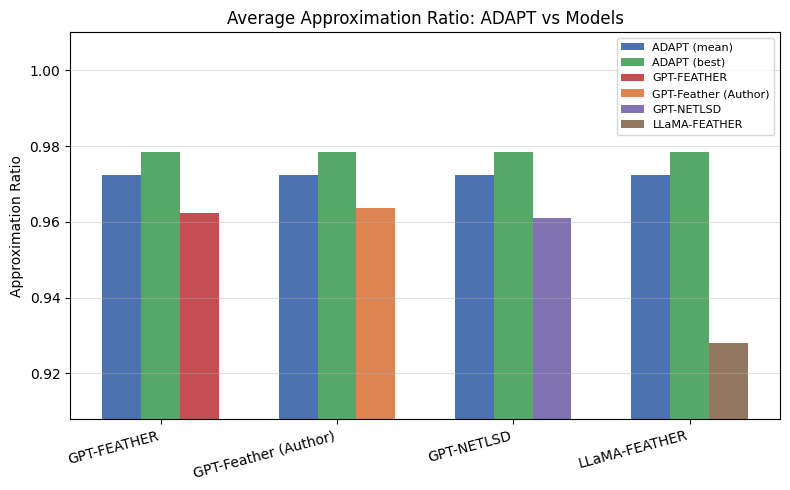

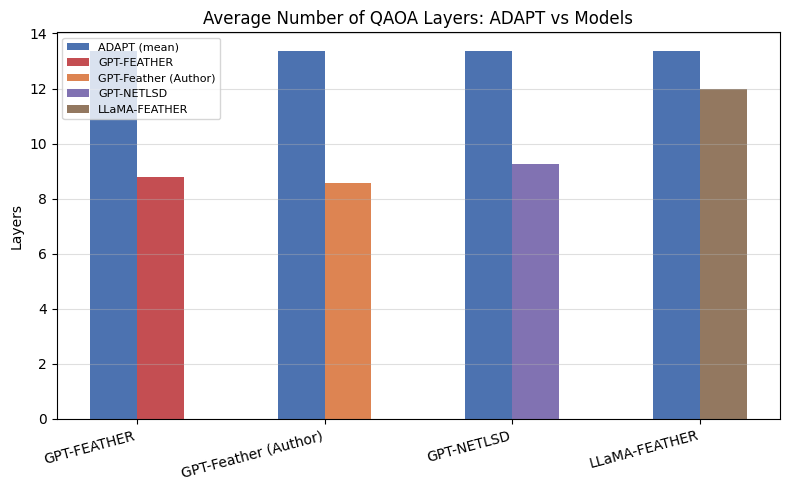

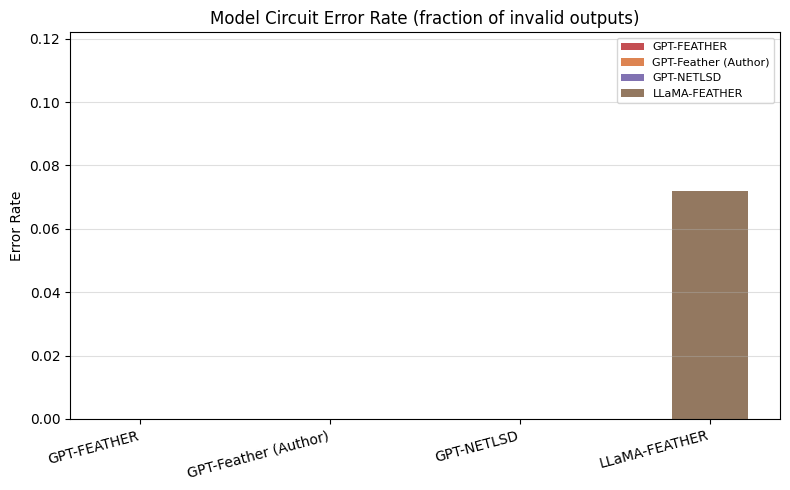

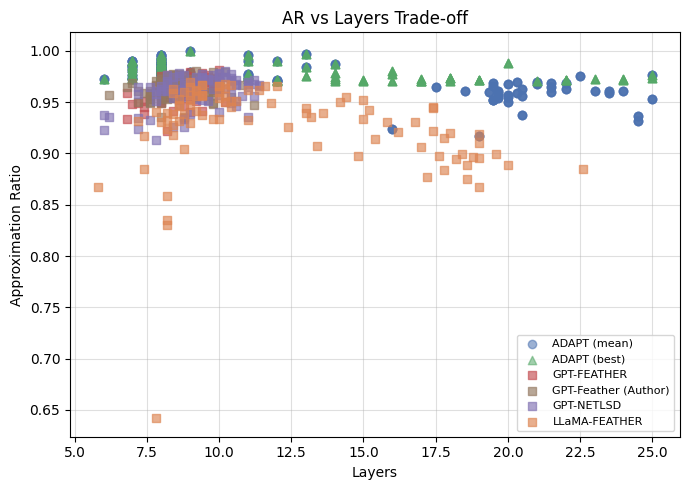

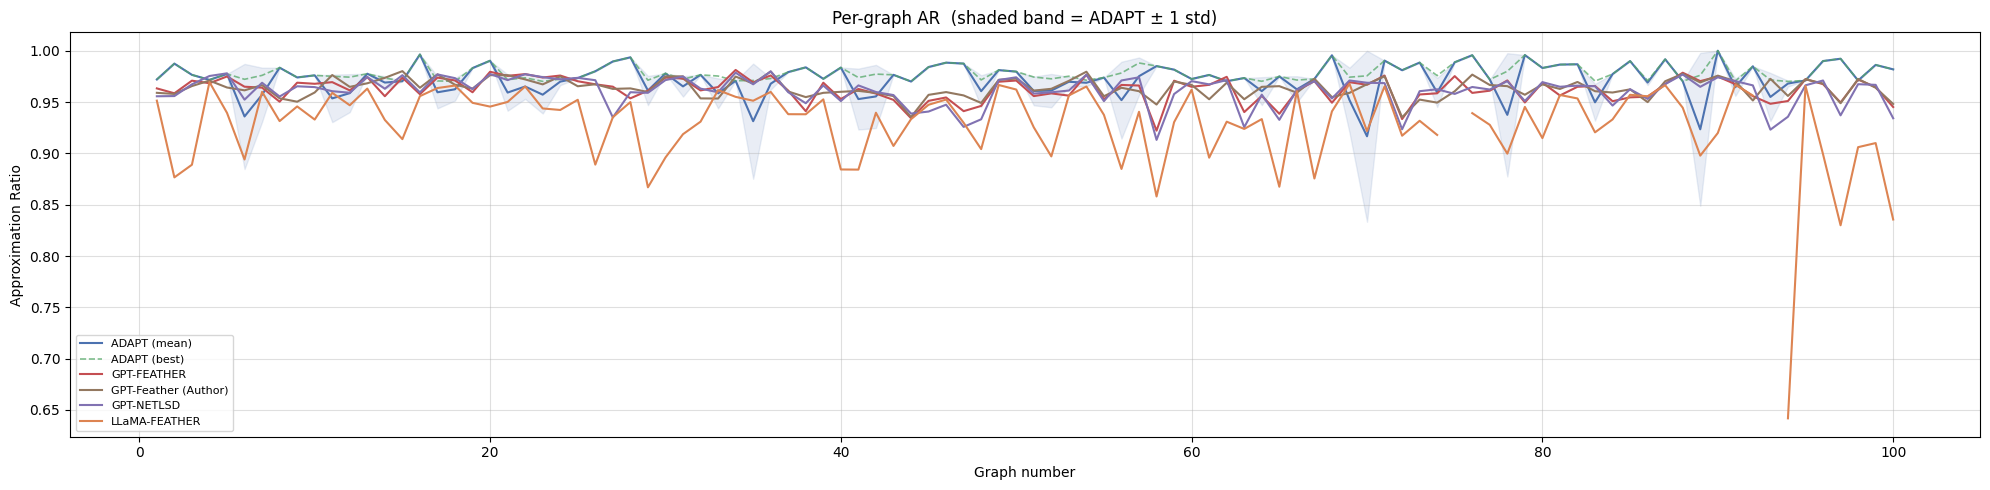

/home/mrzaizai2k/anaconda3/envs/adapt_gpt/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:841: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/mrzaizai2k/anaconda3/envs/adapt_gpt/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:842: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


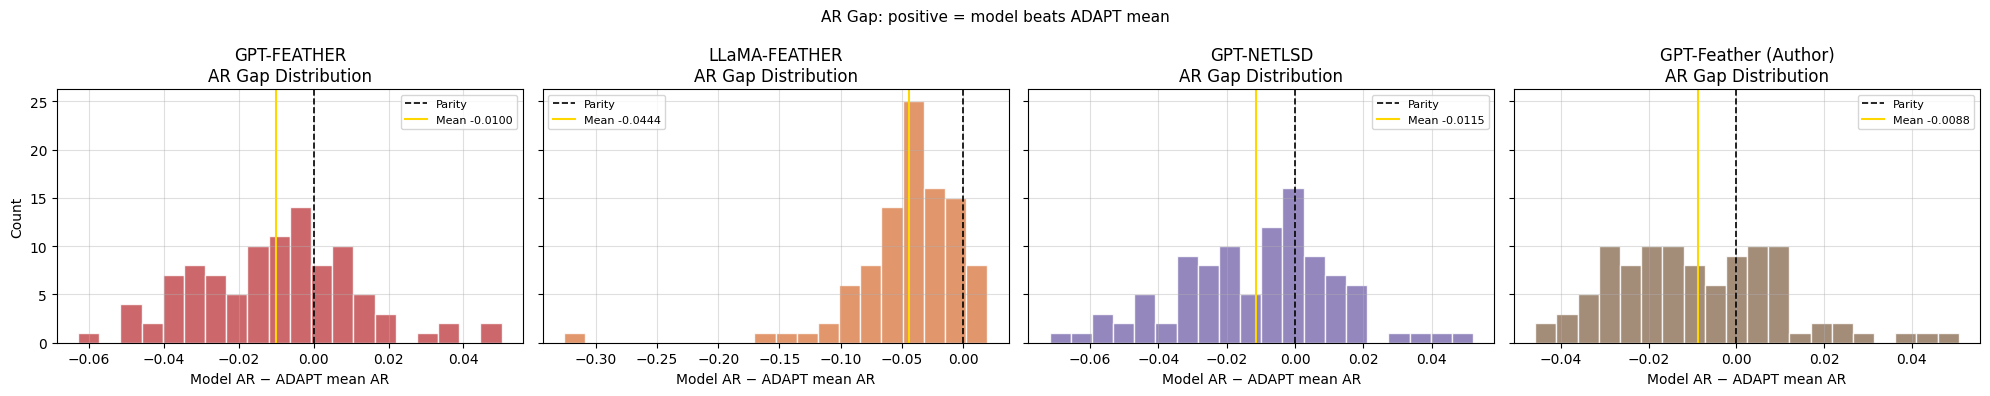

In [58]:
# ── Run all plots ──────────────────────────────────────────────────────────

plot_ar_bar(summary_df)
plot_layers_bar(summary_df)
plot_error_rate_bar(summary_df)
plot_ar_vs_layers_scatter(final_df)
plot_per_graph_ar(final_df)
plot_ar_gap_hist(final_df)

In [59]:
# ------------------------
# EXTRA INSIGHTS
# ------------------------

print("=" * 55)
print("INSIGHTS")
print("=" * 55)

for _, row in summary_df.iterrows():
    print(f"\nModel : {row['model']}")
    print(f"  Graphs evaluated      : {int(row['n_graphs'])}")
    print(f"  ADAPT AR (mean / best): {row['adapt_ar_mean']:.4f} / {row['adapt_ar_best']:.4f}")
    print(f"  Model AR              : {row['model_ar']:.4f}")
    print(f"  AR diff vs mean       : {row['ar_diff_vs_mean']:+.4f}")
    print(f"  AR diff vs best       : {row['ar_diff_vs_best']:+.4f}")
    print(f"  ADAPT layers (mean)   : {row['adapt_layers']:.2f}")
    print(f"  Model layers          : {row['model_layers']:.2f}")
    print(f"  Layer reduction       : {row['adapt_layers'] - row['model_layers']:+.2f}")
    print(f"  Model error rate      : {row['model_error_rate']:.4f}")

n_model_wins_mean = (final_df["ar_diff_vs_mean"] > 0).sum()
n_model_wins_best = (final_df["ar_diff_vs_best"] > 0).sum()
print(f"\n  Graphs where model > ADAPT mean : {n_model_wins_mean} / {len(final_df)}")
print(f"  Graphs where model > ADAPT best : {n_model_wins_best} / {len(final_df)}")

INSIGHTS

Model : GPT-FEATHER
  Graphs evaluated      : 100
  ADAPT AR (mean / best): 0.9724 / 0.9786
  Model AR              : 0.9624
  AR diff vs mean       : -0.0100
  AR diff vs best       : -0.0162
  ADAPT layers (mean)   : 13.37
  Model layers          : 8.79
  Layer reduction       : +4.58
  Model error rate      : 0.0000

Model : GPT-Feather (Author)
  Graphs evaluated      : 100
  ADAPT AR (mean / best): 0.9724 / 0.9786
  Model AR              : 0.9636
  AR diff vs mean       : -0.0088
  AR diff vs best       : -0.0149
  ADAPT layers (mean)   : 13.37
  Model layers          : 8.55
  Layer reduction       : +4.82
  Model error rate      : 0.0000

Model : GPT-NETLSD
  Graphs evaluated      : 100
  ADAPT AR (mean / best): 0.9724 / 0.9786
  Model AR              : 0.9609
  AR diff vs mean       : -0.0115
  AR diff vs best       : -0.0176
  ADAPT layers (mean)   : 13.37
  Model layers          : 9.25
  Layer reduction       : +4.12
  Model error rate      : 0.0000

Model : LLaMA-FE